In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
#from astropy.io import fits
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks
from scipy.stats import skew as calc_skew, kurtosis as calc_kurtosis
import pandas as pd
import os
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [76]:
df = pd.read_csv('features_con_superclass.csv')
#Our Selected features: Skewness, Kurtosis, Amplitude, VonNeumann, Color_V_I
features = df.drop(columns=['ID', 'Period', 'Log_Period', 'R21', 'R31', 'phi21', 'phi31', 'Log_FAP', 'Stetson_J'])
features.head()

,Skewness,Kurtosis,Amplitude,VonNeumann,Color_V_I,SUPERCLASS
0,0.144930,-0.182723,0.1776,2.158303,0.059151,Other
1,-0.521500,-0.868887,0.7350,0.706610,0.590114,Pulsantes
2,0.352394,-0.374508,0.0564,0.269064,1.731065,LPV
3,0.566976,0.164983,0.2608,1.272423,0.127341,Eclipsantes
4,0.257939,0.079751,0.3308,1.953764,-0.010770,Other


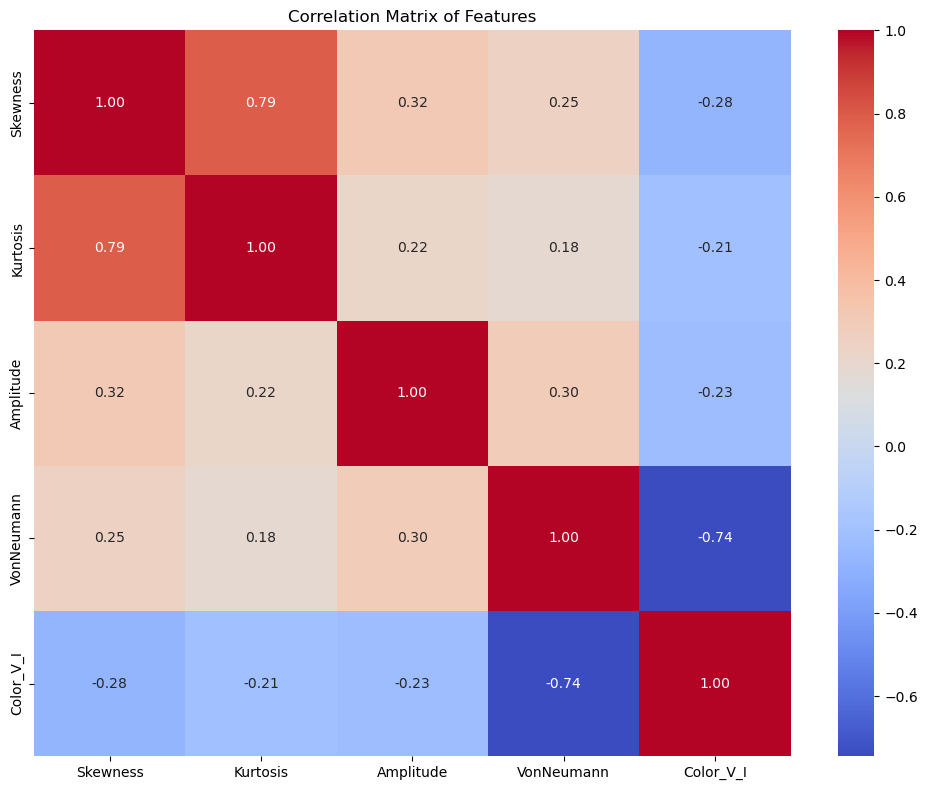

In [77]:
#Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(features.drop(columns=['SUPERCLASS']).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png')

In [78]:
#Por tanto eliminamos Kurtosis
features = features.drop(columns=['Kurtosis'])
features.head()

,Skewness,Amplitude,VonNeumann,Color_V_I,SUPERCLASS
0,0.144930,0.1776,2.158303,0.059151,Other
1,-0.521500,0.7350,0.706610,0.590114,Pulsantes
2,0.352394,0.0564,0.269064,1.731065,LPV
3,0.566976,0.2608,1.272423,0.127341,Eclipsantes
4,0.257939,0.3308,1.953764,-0.010770,Other


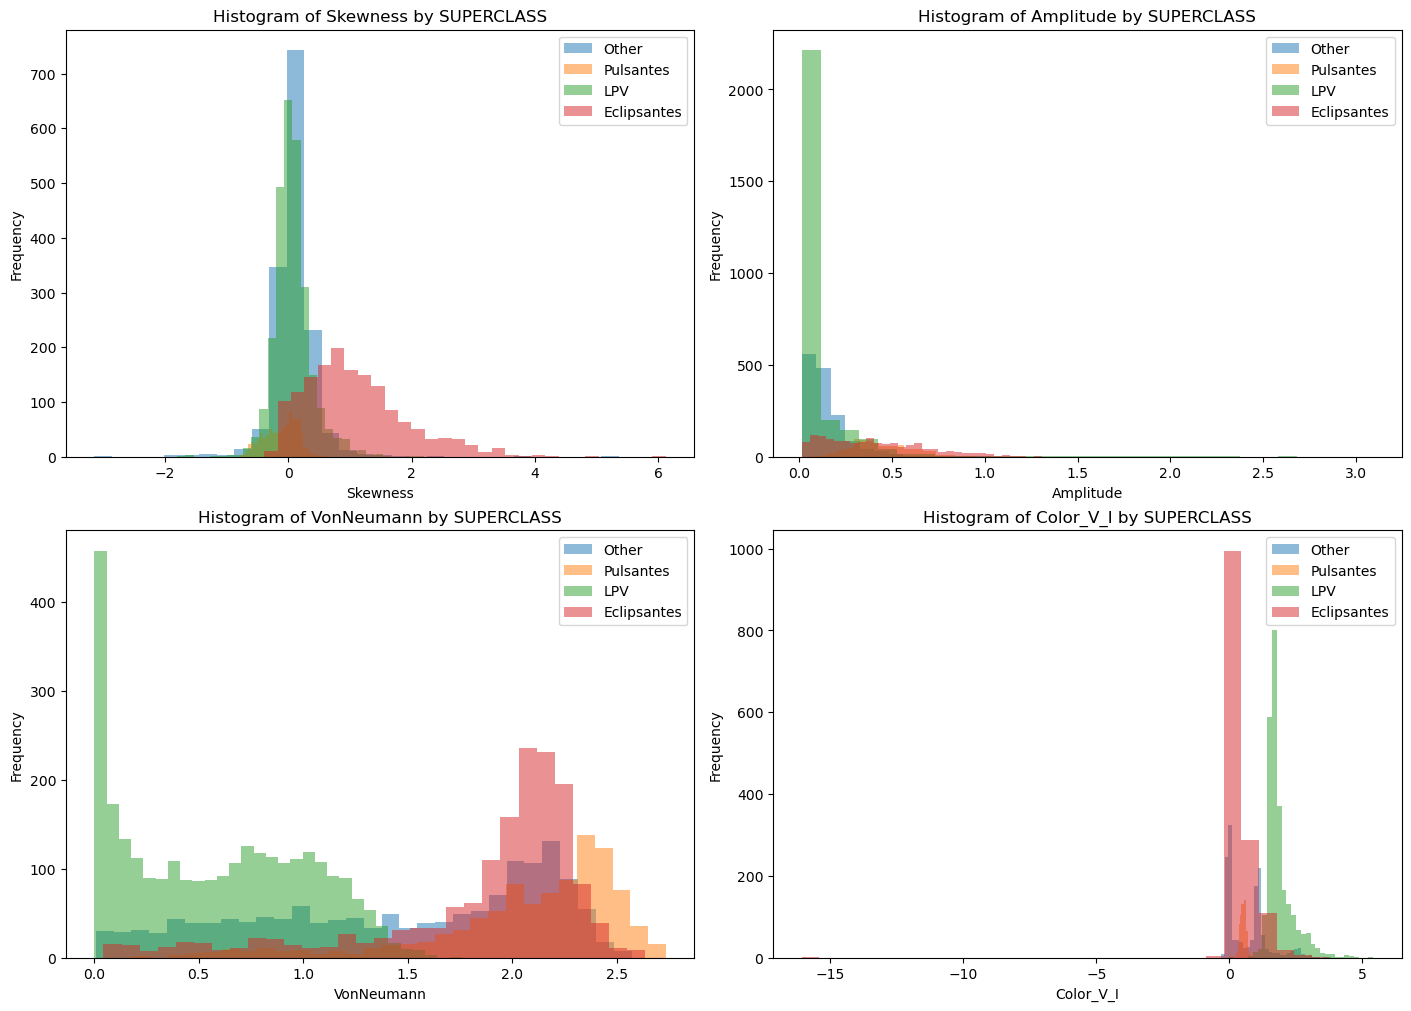

In [79]:
# Histograms of features by superclass in a single figure
feature_list = ['Skewness', 'Amplitude', 'VonNeumann', 'Color_V_I']
superclasses = features['SUPERCLASS'].dropna().unique()

n_features = len(feature_list)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, feature in enumerate(feature_list):
    ax = axes[i]
    for superclass in superclasses:
        subset = features[features['SUPERCLASS'] == superclass]
        ax.hist(subset[feature].dropna(), bins=30, alpha=0.5, label=superclass)
    ax.set_title(f'Histogram of {feature} by SUPERCLASS')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()

# Hide any unused subplot axes
for j in range(n_features, len(axes)):
    axes[j].axis('off')
plt.savefig('histograms_by_superclass.png')
plt.show()

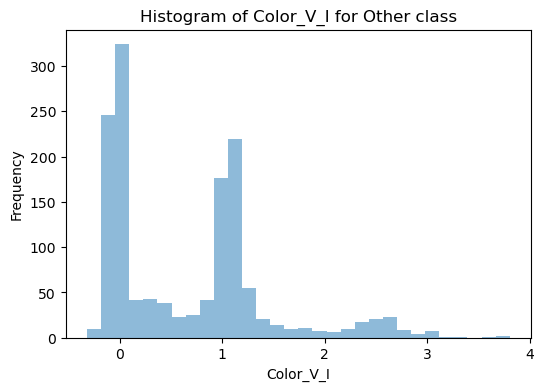

In [80]:
#Histograms of Color V_I fotr Other class
plt.figure(figsize=(6, 4))
other_subset = features[features['SUPERCLASS'] == 'Other']
plt.hist(other_subset['Color_V_I'].dropna(), bins=30, alpha=0.5, label='Other')
plt.title('Histogram of Color_V_I for Other class')
plt.xlabel('Color_V_I')
plt.ylabel('Frequency')
plt.savefig('histogram_color_vi_other.png')

              precision    recall  f1-score   support

 Eclipsantes       0.93      0.83      0.88       287
         LPV       0.95      0.99      0.97       558
       Other       0.87      0.87      0.87       308
   Pulsantes       0.92      0.98      0.95       204

    accuracy                           0.93      1357
   macro avg       0.92      0.92      0.92      1357
weighted avg       0.93      0.93      0.92      1357

Skewness: 0.2675
Amplitude: 0.1919
VonNeumann: 0.1606
Color_V_I: 0.3800


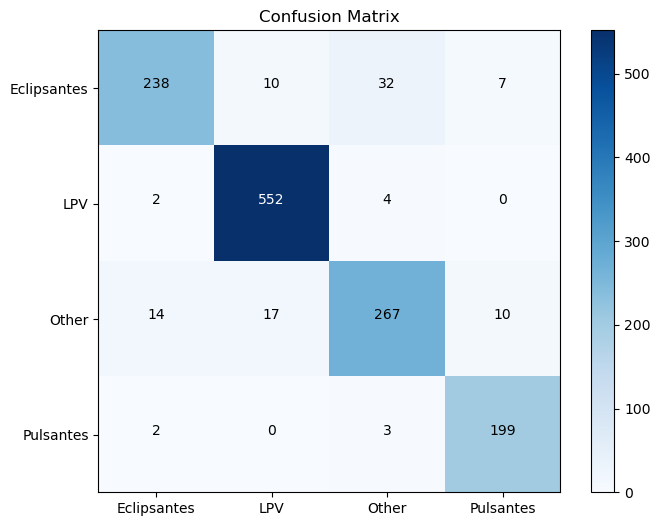

In [81]:
#Random Forest Classifier
X_train, X_test, y_train, y_test = train_test_split(features[feature_list], features['SUPERCLASS'], test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=10)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
for feature, importance in zip(feature_list, rf.feature_importances_):
    print(f'{feature}: {importance:.4f}')
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
#labels
tick_marks = np.arange(len(rf.classes_))
plt.xticks(tick_marks, rf.classes_)
plt.yticks(tick_marks, rf.classes_)
#poner numeros en la matriz
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.colorbar()
plt.savefig('confusion_matrix.png')

              precision    recall  f1-score   support

 Eclipsantes       0.97      0.93      0.95       298
         LPV       0.98      1.00      0.99       563
   Pulsantes       0.97      0.96      0.96       201

    accuracy                           0.97      1062
   macro avg       0.97      0.96      0.97      1062
weighted avg       0.97      0.97      0.97      1062

Skewness: 0.3180
Amplitude: 0.0889
VonNeumann: 0.2309
Color_V_I: 0.3622


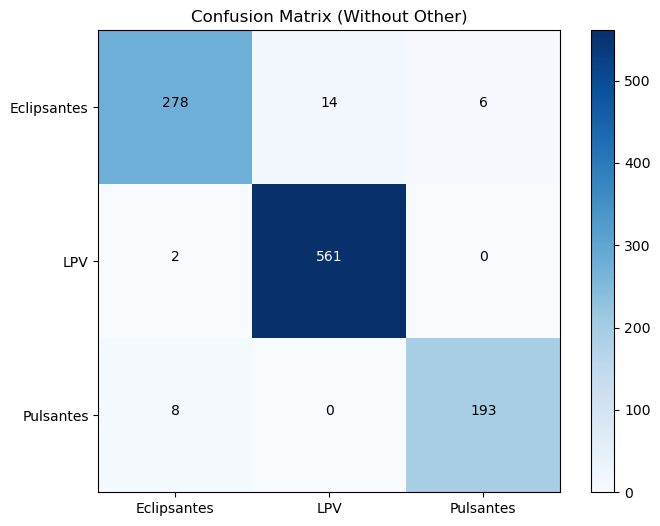

In [83]:
#Si eliminamos la clase Other:
features_no_Other = features[features['SUPERCLASS'] != 'Other']

X_train, X_test, y_train, y_test = train_test_split(features_no_Other[feature_list], features_no_Other['SUPERCLASS'], test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=10)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
for feature, importance in zip(feature_list, rf.feature_importances_):
    print(f'{feature}: {importance:.4f}')
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Without Other)')
tick_marks = np.arange(len(rf.classes_))
plt.xticks(tick_marks, rf.classes_)
plt.yticks(tick_marks, rf.classes_)
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.colorbar()
plt.savefig('confusion_matrix_no_other.png')